# SegTHOR EDA

Change `SAVE_FIGS = True` to save resuts

## 1. Setup

In [ ]:
%matplotlib inline
import csv, json
from pathlib import Path

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy import ndimage as ndi
from skimage.transform import resize
from IPython.display import display

DATA_DIR = Path("data")         
DEST = Path("results/eda")      
SAVE_FIGS = True
SAMPLES_PER_ORGAN = 20_000       
SEED = 0

CLASS_NAMES = {1: "Esophagus", 2: "Heart", 3: "Trachea", 4: "Aorta"}
COLOURS = {1: "#6fae6f", 2: "#f0d080", 3: "#b06a50", 4: "#5ab0d0"}   
LABEL_CMAP = ListedColormap([COLOURS[k] for k in CLASS_NAMES])
SOFT_TISSUE_WINDOW = (-160, 240)  
HU_RANGE, HU_BINS = (-1100, 1600), 270
GRID, THUMB = (256, 256), (128, 128)

DEST.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(SEED)
pd.set_option("display.max_columns", 60)

def save(fig, name):
    if SAVE_FIGS:
        fig.savefig(DEST / name, dpi=130, bbox_inches="tight")

### Helper functions

In [2]:
def load(path):
    image = nib.load(str(path))
    return image, np.asarray(image.dataobj)

def window(img, lo=SOFT_TISSUE_WINDOW[0], hi=SOFT_TISSUE_WINDOW[1]):
    return (np.clip(img.astype(np.float32), lo, hi) - lo) / (hi - lo)

def show_overlay(ax, ct2d, gt2d, title="", aspect=1.0):
    ax.imshow(window(ct2d).T, cmap="gray", vmin=0, vmax=1, origin="lower", aspect=aspect)
    if gt2d is not None:
        ax.imshow(np.ma.masked_where(gt2d.T == 0, gt2d.T), cmap=LABEL_CMAP, vmin=.5, vmax=4.5,
                  alpha=.55, origin="lower", interpolation="nearest", aspect=aspect)
    ax.set_title(title, fontsize=9)
    ax.axis("off")

def bounding_box(mask):
    out = []
    for axis in range(mask.ndim):
        other = tuple(a for a in range(mask.ndim) if a != axis)
        idx = np.flatnonzero(mask.any(axis=other))
        out.append(slice(idx[0], idx[-1] + 1))
    return tuple(out)

def scan_stats(patient, split, image, ct):
    dx, dy, dz = (float(s) for s in image.header.get_zooms()[:3])
    p = np.percentile(ct, [0.5, 1, 50, 99, 99.5])
    return {"patient": patient, "split": split,
            "shape_x": ct.shape[0], "shape_y": ct.shape[1], "n_slices": ct.shape[2],
            "spacing_x": dx, "spacing_y": dy, "spacing_z": dz,
            "orientation": "".join(nib.aff2axcodes(image.affine)), "dtype": str(ct.dtype),
            "hu_min": float(ct.min()), "hu_p0.5": float(p[0]), "hu_p1": float(p[1]),
            "hu_median": float(p[2]), "hu_p99": float(p[3]), "hu_p99.5": float(p[4]),
            "hu_max": float(ct.max())}

def organ_stats(gt, spacing, k):
    mask, name = gt == k, CLASS_NAMES[k].lower()
    n = int(mask.sum())
    rec = {f"{name}_voxels": n, f"{name}_ml": n * float(np.prod(spacing)) / 1000}
    if n == 0:
        return rec | {f"{name}_slices": 0, f"{name}_components": 0}
    z_present = mask.any(axis=(0, 1))
    rec[f"{name}_slices"] = int(z_present.sum())
    rec[f"{name}_z_first"] = int(np.argmax(z_present))
    rec[f"{name}_z_last"] = int(len(z_present) - 1 - np.argmax(z_present[::-1]))
    # 26-connected components: an organ should be one piece
    labelled, count = ndi.label(mask[bounding_box(mask)], structure=np.ones((3, 3, 3), bool))
    sizes = np.bincount(labelled.ravel())[1:]
    rec[f"{name}_components"] = int(count)
    rec[f"{name}_largest_frac"] = float(sizes.max() / sizes.sum())
    return rec

def best_slice(gt):
    # axial slice showing the most organs (ties -> most labelled area)
    present = np.stack([(gt == k).any(axis=(0, 1)) for k in CLASS_NAMES])
    return int(np.argmax(present.sum(0) * 1e7 + np.count_nonzero(gt, axis=(0, 1))))

## 3. Find the data

Lists every patient folder and checks that both files are there before anything heavy is loaded.

In [3]:
train_dir, test_dir = DATA_DIR / "train", DATA_DIR / "test"
assert train_dir.is_dir(), f"No train/ folder in {DATA_DIR.resolve()}"

patients = sorted(p for p in train_dir.glob("Patient_*") if p.is_dir())
test_scans = sorted(test_dir.glob("Patient_*.nii.gz")) if test_dir.is_dir() else []

inventory = pd.DataFrame([{"patient": p.name,
                           "CT found": (p / f"{p.name}.nii.gz").is_file(),
                           "GT found": (p / "GT.nii.gz").is_file(),
                           "other files": ", ".join(sorted(f.name for f in p.iterdir()
                                                    if f.name not in {f"{p.name}.nii.gz", "GT.nii.gz"}))}
                          for p in patients])
print(f"{len(patients)} training patients, {len(test_scans)} test scans")
display(inventory)
if not inventory.empty and not (inventory["CT found"] & inventory["GT found"]).all():
    print("⚠ Some patients are missing files — check the file names in the 'other files' column.")

40 training patients, 0 test scans


,patient,CT found,GT found,other files
0,Patient_01,True,True,
1,Patient_02,True,True,
2,Patient_03,True,True,
3,Patient_04,True,True,
4,Patient_05,True,True,
5,Patient_06,True,True,
6,Patient_07,True,True,
7,Patient_08,True,True,
8,Patient_09,True,True,
9,Patient_10,True,True,


## 4. A first look at one patient

Axial, coronal and sagittal views through the middle of the labelled region. Change `i` to look at another patient.

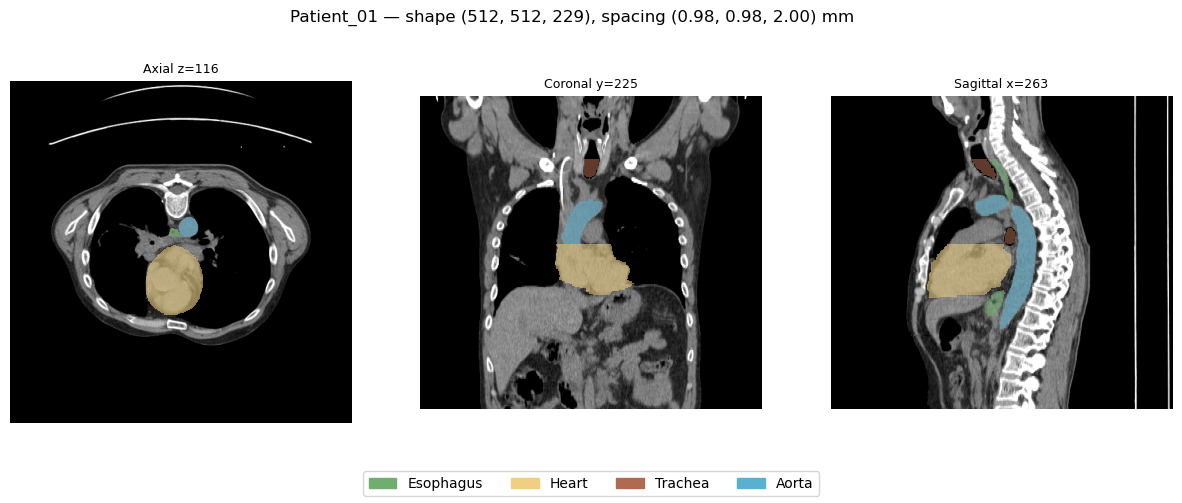

In [4]:
i = 0
pdir = patients[i]
ct_img, ct = load(pdir / f"{pdir.name}.nii.gz")
_, gt = load(pdir / "GT.nii.gz")
dx, dy, dz = ct_img.header.get_zooms()[:3]
cx, cy, cz = [int((s.start + s.stop) / 2) for s in bounding_box(gt > 0)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
show_overlay(axes[0], ct[:, :, cz], gt[:, :, cz], f"Axial z={cz}", aspect=dy / dx)
show_overlay(axes[1], ct[:, cy, :], gt[:, cy, :], f"Coronal y={cy}", aspect=dz / dx)
show_overlay(axes[2], ct[cx, :, :], gt[cx, :, :], f"Sagittal x={cx}", aspect=dz / dy)
handles = [plt.Rectangle((0, 0), 1, 1, color=COLOURS[k]) for k in CLASS_NAMES]
fig.legend(handles, CLASS_NAMES.values(), loc="lower center", ncol=4)
fig.suptitle(f"{pdir.name} — shape {ct.shape}, spacing ({dx:.2f}, {dy:.2f}, {dz:.2f}) mm")
plt.show()
del ct, gt

## 5. Process every patient

The figure below updates in place as each patient is loaded: left, its most informative slice; right, running organ volumes. Takes a few seconds per patient.

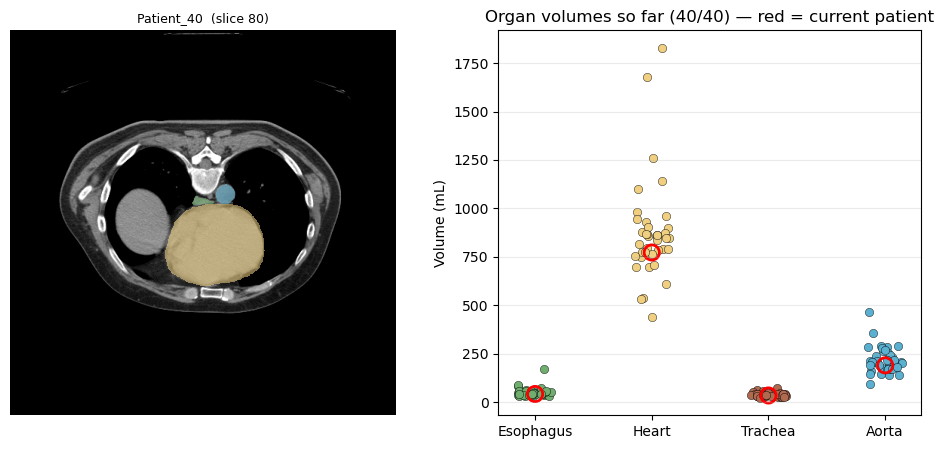


Done: 40 training patients, 0 test scans, 0 warning(s).


In [5]:
records, warnings, thumbs = [], [], []
hists = {"train": np.zeros(HU_BINS), "test": np.zeros(HU_BINS)}
organ_samples = {k: [] for k in CLASS_NAMES}
heat = {k: np.zeros(GRID) for k in CLASS_NAMES}
class_voxels = np.zeros(5)

live_fig, (ax_img, ax_vol) = plt.subplots(1, 2, figsize=(12, 5))
handle = display(live_fig, display_id=True)
plt.close(live_fig)

for n, pdir in enumerate(patients, 1):
    pid = pdir.name
    ct_path, gt_path = pdir / f"{pid}.nii.gz", pdir / "GT.nii.gz"
    if not (ct_path.is_file() and gt_path.is_file()):
        warnings.append(f"{pid}: missing CT or GT file, skipped")
        continue

    ct_img, ct = load(ct_path)
    gt_img, gt = load(gt_path)
    rec = scan_stats(pid, "train", ct_img, ct)
    hists["train"] += np.histogram(ct, bins=HU_BINS, range=HU_RANGE)[0]

    # integrity checks
    if ct.shape != gt.shape:
        warnings.append(f"{pid}: CT shape {ct.shape} != GT shape {gt.shape}, skipped")
        records.append(rec)
        continue
    if not np.allclose(ct_img.affine, gt_img.affine, atol=1e-3):
        warnings.append(f"{pid}: CT and GT affines differ")
    values = set(np.unique(gt).astype(int).tolist())
    if values - set(range(5)):
        warnings.append(f"{pid}: unexpected label values {sorted(values - set(range(5)))}")
    for k in CLASS_NAMES:
        if k not in values:
            warnings.append(f"{pid}: {CLASS_NAMES[k]} (label {k}) is missing")

    gt = gt.astype(np.uint8)
    spacing = ct_img.header.get_zooms()[:3]
    class_voxels += np.bincount(gt.ravel(), minlength=5)[:5]
    rec["empty_slices"] = int((~gt.any(axis=(0, 1))).sum())

    for k in CLASS_NAMES:
        name = CLASS_NAMES[k].lower()
        rec |= organ_stats(gt, spacing, k)
        if rec[f"{name}_components"] > 1:
            warnings.append(f"{pid}: {CLASS_NAMES[k]} has {rec[f'{name}_components']} pieces "
                            f"(largest = {100 * rec[f'{name}_largest_frac']:.1f}%)")
        mask = gt == k
        if mask.any():
            hu = ct[mask]
            organ_samples[k].append(rng.choice(hu, min(SAMPLES_PER_ORGAN, hu.size), replace=False))
            rec[f"{name}_hu_median"] = float(np.median(hu))
            heat[k] += resize(mask.any(axis=2).astype(np.uint8), GRID, order=0,
                              preserve_range=True, anti_aliasing=False) > 0

    z = best_slice(gt)
    thumbs.append((pid, z,
                   resize(window(ct[:, :, z]), THUMB, order=1, preserve_range=True, anti_aliasing=True),
                   resize(gt[:, :, z], THUMB, order=0, preserve_range=True,
                          anti_aliasing=False).astype(np.uint8)))
    records.append(rec)

    # live update
    ax_img.clear(); ax_vol.clear()
    show_overlay(ax_img, ct[:, :, z], gt[:, :, z], f"{pid}  (slice {z})", aspect=spacing[1] / spacing[0])
    done = [r for r in records if "empty_slices" in r]
    for j, k in enumerate(CLASS_NAMES):
        v = [r[f"{CLASS_NAMES[k].lower()}_ml"] for r in done]
        ax_vol.scatter(np.full(len(v), j) + rng.uniform(-.15, .15, len(v)), v,
                       color=COLOURS[k], edgecolor="k", linewidth=.3)
        ax_vol.scatter([j], [v[-1]], s=120, facecolor="none", edgecolor="red", linewidth=2)
    ax_vol.set_xticks(range(4)); ax_vol.set_xticklabels(CLASS_NAMES.values())
    ax_vol.set_ylabel("Volume (mL)"); ax_vol.grid(axis="y", alpha=.25)
    ax_vol.set_title(f"Organ volumes so far ({n}/{len(patients)}) — red = current patient")
    handle.update(live_fig)
    del ct, gt

for path in test_scans:
    pid = path.name.replace(".nii.gz", "")
    img, ct = load(path)
    records.append(scan_stats(pid, "test", img, ct))
    hists["test"] += np.histogram(ct, bins=HU_BINS, range=HU_RANGE)[0]
    print(f"test scan {pid} done", end="\r")

organ_samples = {k: np.concatenate(v) if v else np.array([]) for k, v in organ_samples.items()}
df = pd.DataFrame(records)
train = df[(df["split"] == "train") & df.get("empty_slices", pd.Series(dtype=float)).notna()].reset_index(drop=True)
df.to_csv(DEST / "per_patient.csv", index=False)
print(f"\nDone: {len(train)} training patients, {len(test_scans)} test scans, {len(warnings)} warning(s).")

## 6. Data-integrity warnings
Empty means the professor's claim that the data is clean holds up.

In [16]:
if warnings:
    for w in warnings:
        print("•", w)
else:
    print("No problems found: shapes and affines match, labels are 0–4, every organ presenin one piece.")

No problems found: shapes and affines match, labels are 0–4, every organ presenin one piece.


## 7. Per-patient table

In [7]:
geom_cols = ["patient", "split", "shape_x", "shape_y", "n_slices", "spacing_x", "spacing_z",
             "orientation", "hu_min", "hu_p1", "hu_median", "hu_p99", "hu_max"]
display(df[geom_cols].round(2))
vol_cols = ["patient"] + [f"{n.lower()}_ml" for n in CLASS_NAMES.values()] \
         + [f"{n.lower()}_components" for n in CLASS_NAMES.values()]
display(train[vol_cols].round(1))
display(train[[c for c in vol_cols if c.endswith("_ml")]].describe().round(1))

,patient,split,shape_x,shape_y,n_slices,spacing_x,spacing_z,orientation,hu_min,hu_p1,hu_median,hu_p99,hu_max
0,Patient_01,train,512,512,229,0.98,2.0,LPS,-1000.0,-1000.0,-994.0,245.0,3071.0
1,Patient_02,train,512,512,246,0.98,2.5,LPS,-1000.0,-1000.0,-965.0,367.0,26613.0
2,Patient_03,train,512,512,147,0.98,2.5,LPS,-1000.0,-1000.0,-978.0,276.0,25292.0
3,Patient_04,train,512,512,158,0.98,2.5,LPS,-1000.0,-1000.0,-967.0,312.0,4551.0
4,Patient_05,train,512,512,284,0.98,2.0,LPS,-1000.0,-1000.0,-996.0,384.0,3071.0
5,Patient_06,train,512,512,199,0.98,2.5,LPS,-1000.0,-1000.0,-989.0,313.0,3071.0
6,Patient_07,train,512,512,179,0.98,2.0,LPS,-1000.0,-1000.0,-984.0,259.0,3059.0
7,Patient_08,train,512,512,171,0.98,2.5,LPS,-1000.0,-1000.0,-993.0,317.0,3071.0
8,Patient_09,train,512,512,154,0.98,2.5,LPS,-1000.0,-1000.0,-994.0,366.0,3071.0
9,Patient_10,train,512,512,163,0.98,2.0,LPS,-1000.0,-1000.0,-949.0,390.0,3071.0


,patient,esophagus_ml,heart_ml,trachea_ml,aorta_ml,esophagus_components,heart_components,trachea_components,aorta_components
0,Patient_01,61.8,697.4,61.1,203.2,1,1,1,1
1,Patient_02,46.3,857.4,34.0,204.9,1,1,1,1
2,Patient_03,32.1,438.0,30.1,94.8,1,1,1,1
3,Patient_04,44.7,788.0,52.0,356.6,1,1,1,1
4,Patient_05,81.1,866.7,49.3,224.1,1,1,1,1
5,Patient_06,45.4,899.9,41.6,285.9,1,1,1,1
6,Patient_07,48.4,697.8,28.2,171.4,1,1,1,1
7,Patient_08,35.8,607.2,41.2,201.6,1,1,1,1
8,Patient_09,38.4,872.9,56.0,141.9,1,1,1,1
9,Patient_10,52.0,931.4,38.0,207.4,1,1,1,1


,esophagus_ml,heart_ml,trachea_ml,aorta_ml
count,40.0,40.0,40.0,40.0
mean,50.7,871.5,38.7,216.1
std,22.9,255.7,10.3,66.5
min,30.6,438.0,21.7,94.8
25%,40.6,764.7,32.2,172.5
50%,45.8,847.0,38.0,206.1
75%,53.2,901.2,42.0,247.4
max,169.5,1829.3,72.9,465.2


## 8. Acquisition geometry

Every slice gets resized to 256×256 regardless of its pixel spacing, and slices are treated independently regardless of thickness.

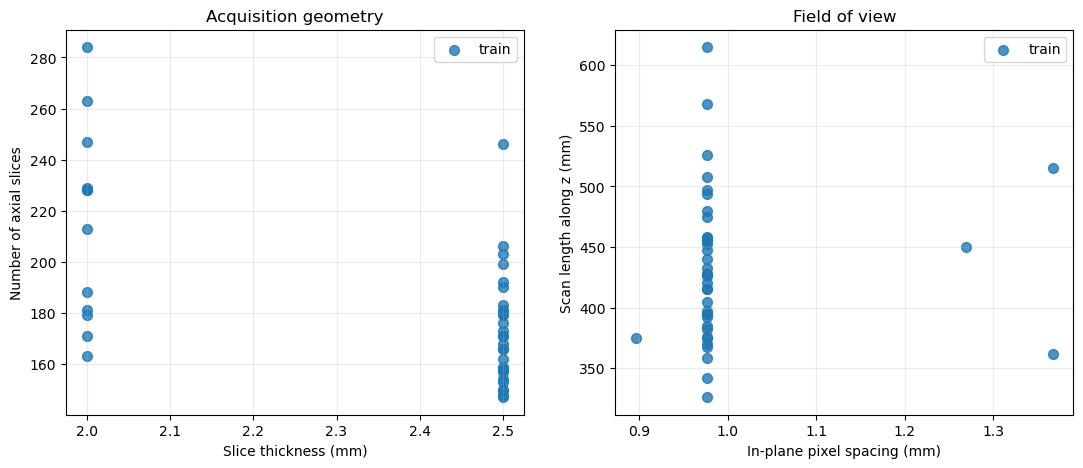

Orientations: ['LPS'] | in-plane shapes: ['512x512']


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for split, c in [("train", "tab:blue"), ("test", "tab:orange")]:
    d = df[df["split"] == split]
    if d.empty: continue
    axes[0].scatter(d["spacing_z"], d["n_slices"], s=50, label=split, color=c, alpha=.8)
    axes[1].scatter(d["spacing_x"], d["n_slices"] * d["spacing_z"], s=50, label=split, color=c, alpha=.8)
axes[0].set(xlabel="Slice thickness (mm)", ylabel="Number of axial slices", title="Acquisition geometry")
axes[1].set(xlabel="In-plane pixel spacing (mm)", ylabel="Scan length along z (mm)", title="Field of view")
for ax in axes: ax.grid(alpha=.25); ax.legend()
save(fig, "01_geometry.png"); plt.show()
print("Orientations:", df["orientation"].unique(), "| in-plane shapes:",
      (df["shape_x"].astype(str) + "x" + df["shape_y"].astype(str)).unique())

## 9. Intensities

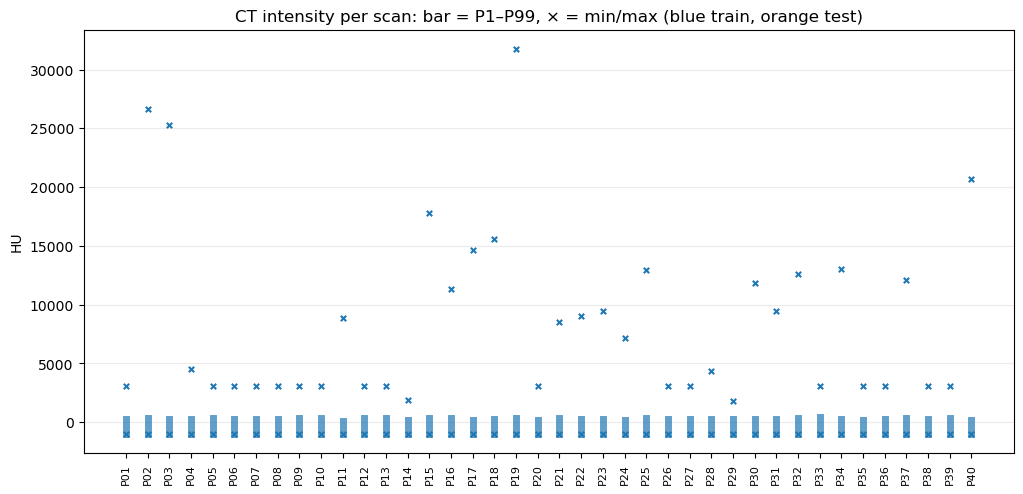

In [9]:
fig, ax = plt.subplots(figsize=(max(10, .3 * len(df)), 5.5))
for i, r in df.iterrows():
    c = "tab:blue" if r["split"] == "train" else "tab:orange"
    ax.plot([i, i], [r["hu_p1"], r["hu_p99"]], color=c, linewidth=5, alpha=.7)
    ax.scatter([i, i], [r["hu_min"], r["hu_max"]], color=c, s=15, marker="x")
ax.set_xticks(range(len(df)))
ax.set_xticklabels(df["patient"].str.replace("Patient_", "P"), rotation=90, fontsize=8)
ax.set(ylabel="HU", title="CT intensity per scan: bar = P1–P99, × = min/max (blue train, orange test)")
ax.grid(axis="y", alpha=.25)
save(fig, "02_intensity_ranges.png"); plt.show()

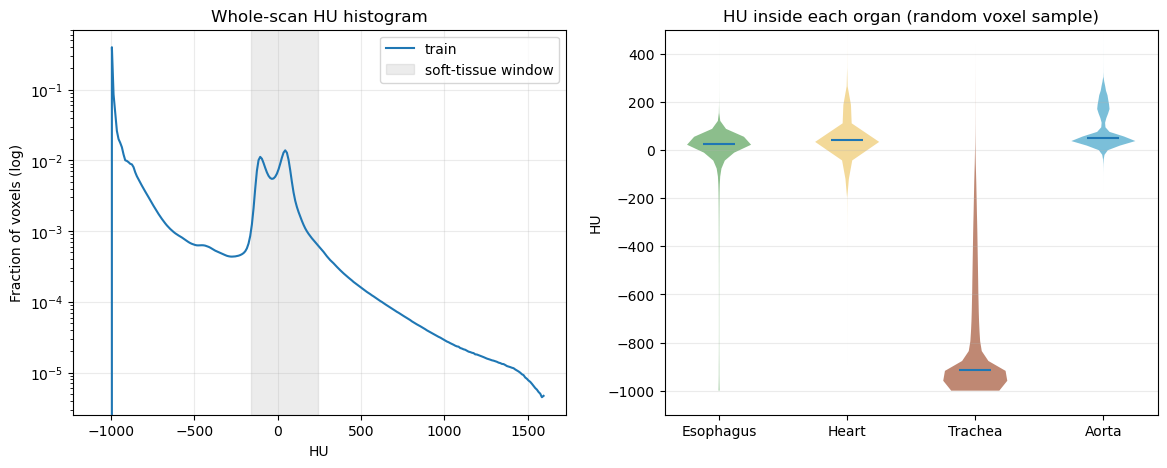

        Esophagus  Heart  Trachea  Aorta
P1         -910.0 -131.0  -1000.0  -15.0
P5         -221.0  -85.0  -1000.0    8.0
median       25.0   40.0   -914.0   50.0
P95          82.0  190.0   -285.0  236.0
P99         114.0  245.0    -88.0  276.0


In [10]:
edges = np.linspace(*HU_RANGE, HU_BINS + 1); centres = (edges[:-1] + edges[1:]) / 2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for split, c in [("train", "tab:blue"), ("test", "tab:orange")]:
    h = hists[split]
    if h.sum(): axes[0].plot(centres, h / h.sum(), label=split, color=c)
axes[0].axvspan(*SOFT_TISSUE_WINDOW, color="grey", alpha=.15, label="soft-tissue window")
axes[0].set_yscale("log"); axes[0].legend(); axes[0].grid(alpha=.25)
axes[0].set(xlabel="HU", ylabel="Fraction of voxels (log)", title="Whole-scan HU histogram")

ks = [k for k in CLASS_NAMES if organ_samples[k].size]
parts = axes[1].violinplot([organ_samples[k] for k in ks], showmedians=True, showextrema=False)
for body, k in zip(parts["bodies"], ks):
    body.set_facecolor(COLOURS[k]); body.set_alpha(.8)
axes[1].set_xticks(range(1, len(ks) + 1)); axes[1].set_xticklabels([CLASS_NAMES[k] for k in ks])
axes[1].set_ylim(-1100, 500); axes[1].grid(axis="y", alpha=.25)
axes[1].set(ylabel="HU", title="HU inside each organ (random voxel sample)")
save(fig, "03_hu_distributions.png"); plt.show()

print(pd.DataFrame({CLASS_NAMES[k]: np.percentile(organ_samples[k], [1, 5, 50, 95, 99])
                    for k in ks}, index=["P1", "P5", "median", "P95", "P99"]).round(0))

## 10. Class balance


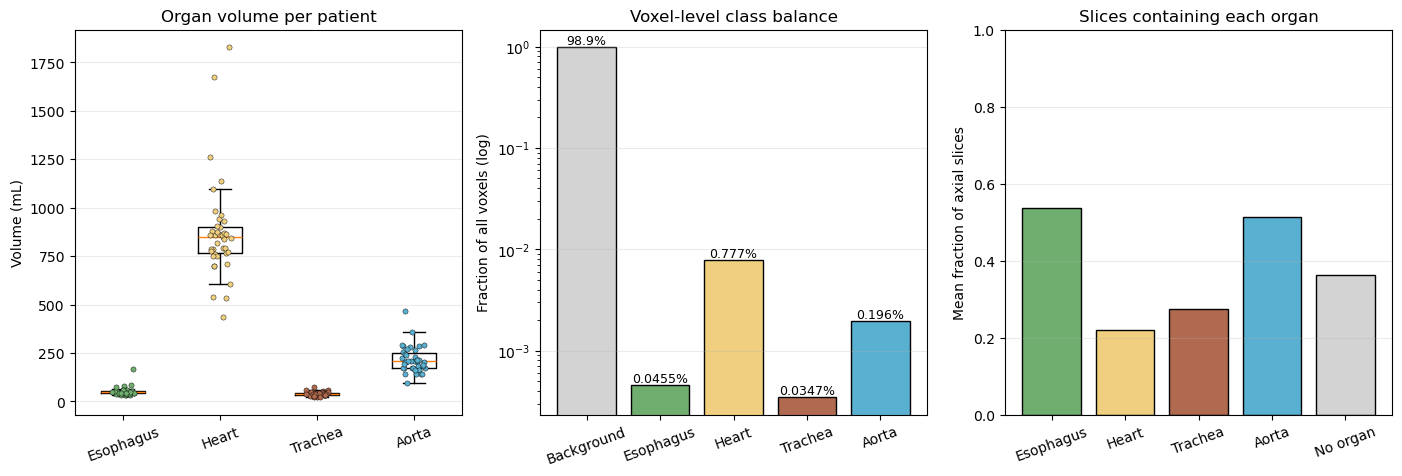

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
vols = [train[f"{CLASS_NAMES[k].lower()}_ml"].to_numpy() for k in CLASS_NAMES]
axes[0].boxplot(vols, showfliers=False)
for i, (k, v) in enumerate(zip(CLASS_NAMES, vols), 1):
    axes[0].scatter(i + rng.uniform(-.12, .12, len(v)), v, s=14, color=COLOURS[k],
                    edgecolor="k", linewidth=.3, zorder=3)
axes[0].set_xticks(range(1, 5)); axes[0].set_xticklabels(CLASS_NAMES.values())
axes[0].set(ylabel="Volume (mL)", title="Organ volume per patient")

frac = class_voxels / class_voxels.sum()
axes[1].bar(["Background", *CLASS_NAMES.values()], frac,
            color=["lightgrey", *COLOURS.values()], edgecolor="k")
axes[1].set_yscale("log")
for i, f in enumerate(frac):
    axes[1].text(i, f, f"{100 * f:.3g}%", ha="center", va="bottom", fontsize=9)
axes[1].set(ylabel="Fraction of all voxels (log)", title="Voxel-level class balance")

slice_frac = [(train[f"{CLASS_NAMES[k].lower()}_slices"] / train["n_slices"]).mean() for k in CLASS_NAMES]
empty = (train["empty_slices"] / train["n_slices"]).mean()
axes[2].bar([*CLASS_NAMES.values(), "No organ"], [*slice_frac, empty],
            color=[*COLOURS.values(), "lightgrey"], edgecolor="k")
axes[2].set_ylim(0, 1)
axes[2].set(ylabel="Mean fraction of axial slices", title="Slices containing each organ")
for ax in axes: ax.grid(axis="y", alpha=.25); ax.tick_params(axis="x", rotation=20)
save(fig, "04_class_balance.png"); plt.show()

## 11. Where the organs are
Axial extent of each organ along the scan, per patient.

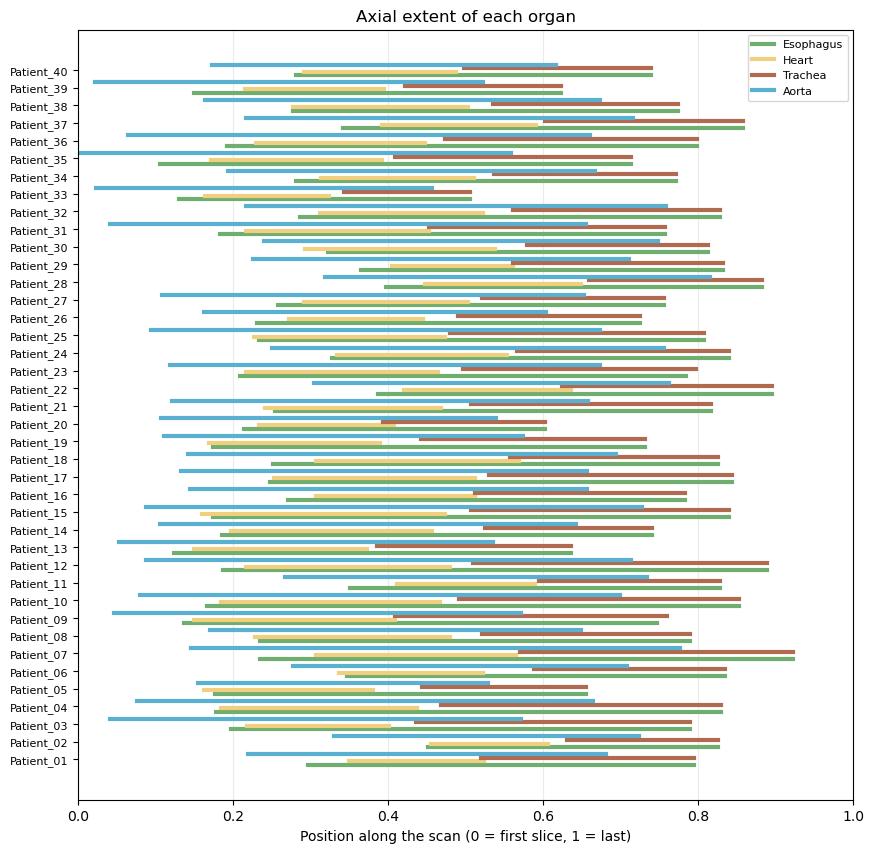

In [12]:
fig, ax = plt.subplots(figsize=(10, max(5, .25 * len(train))))
offsets = {1: -.3, 2: -.1, 3: .1, 4: .3}
for i, (_, r) in enumerate(train.iterrows()):
    for k in CLASS_NAMES:
        name = CLASS_NAMES[k].lower()
        if pd.isna(r.get(f"{name}_z_first")): continue
        a, b = r[f"{name}_z_first"] / r["n_slices"], (r[f"{name}_z_last"] + 1) / r["n_slices"]
        ax.plot([a, b], [i + offsets[k]] * 2, color=COLOURS[k], linewidth=3,
                label=CLASS_NAMES[k] if i == 0 else None)
ax.set_yticks(range(len(train))); ax.set_yticklabels(train["patient"], fontsize=8)
ax.set_xlim(0, 1); ax.grid(axis="x", alpha=.25); ax.legend(loc="upper right", fontsize=8)
ax.set(xlabel="Position along the scan (0 = first slice, 1 = last)", title="Axial extent of each organ")
save(fig, "05_organ_z_extent.png"); plt.show()

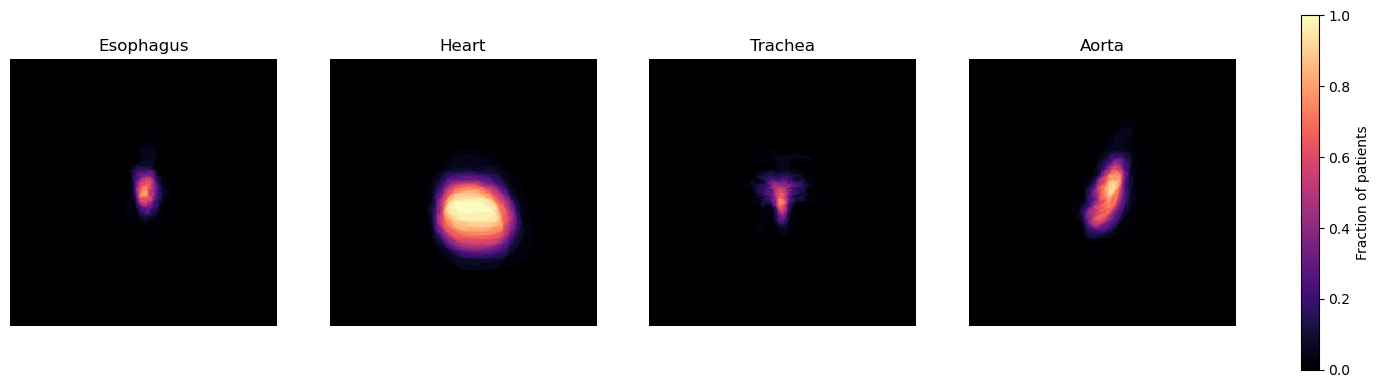

All organs fall inside x = [90, 196), y = [53, 200) of the 256×256 grid


In [13]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4.6))
for ax, k in zip(axes, CLASS_NAMES):
    im = ax.imshow((heat[k] / len(train)).T, origin="lower", vmin=0, vmax=1, cmap="magma",
                   interpolation="nearest")
    ax.set_title(CLASS_NAMES[k]); ax.axis("off")
fig.colorbar(im, ax=axes, fraction=.02, label="Fraction of patients")
save(fig, "06_organ_occupancy.png"); plt.show()

union = np.any([heat[k] > 0 for k in CLASS_NAMES], axis=0)
if union.any():
    bb = bounding_box(union)
    print(f"All organs fall inside x = [{bb[0].start}, {bb[0].stop}), y = [{bb[1].start}, {bb[1].stop}) "
          f"of the {GRID[0]}×{GRID[1]} grid")

## 12. Visual check of every patient
One slice per patient with labels overlaid

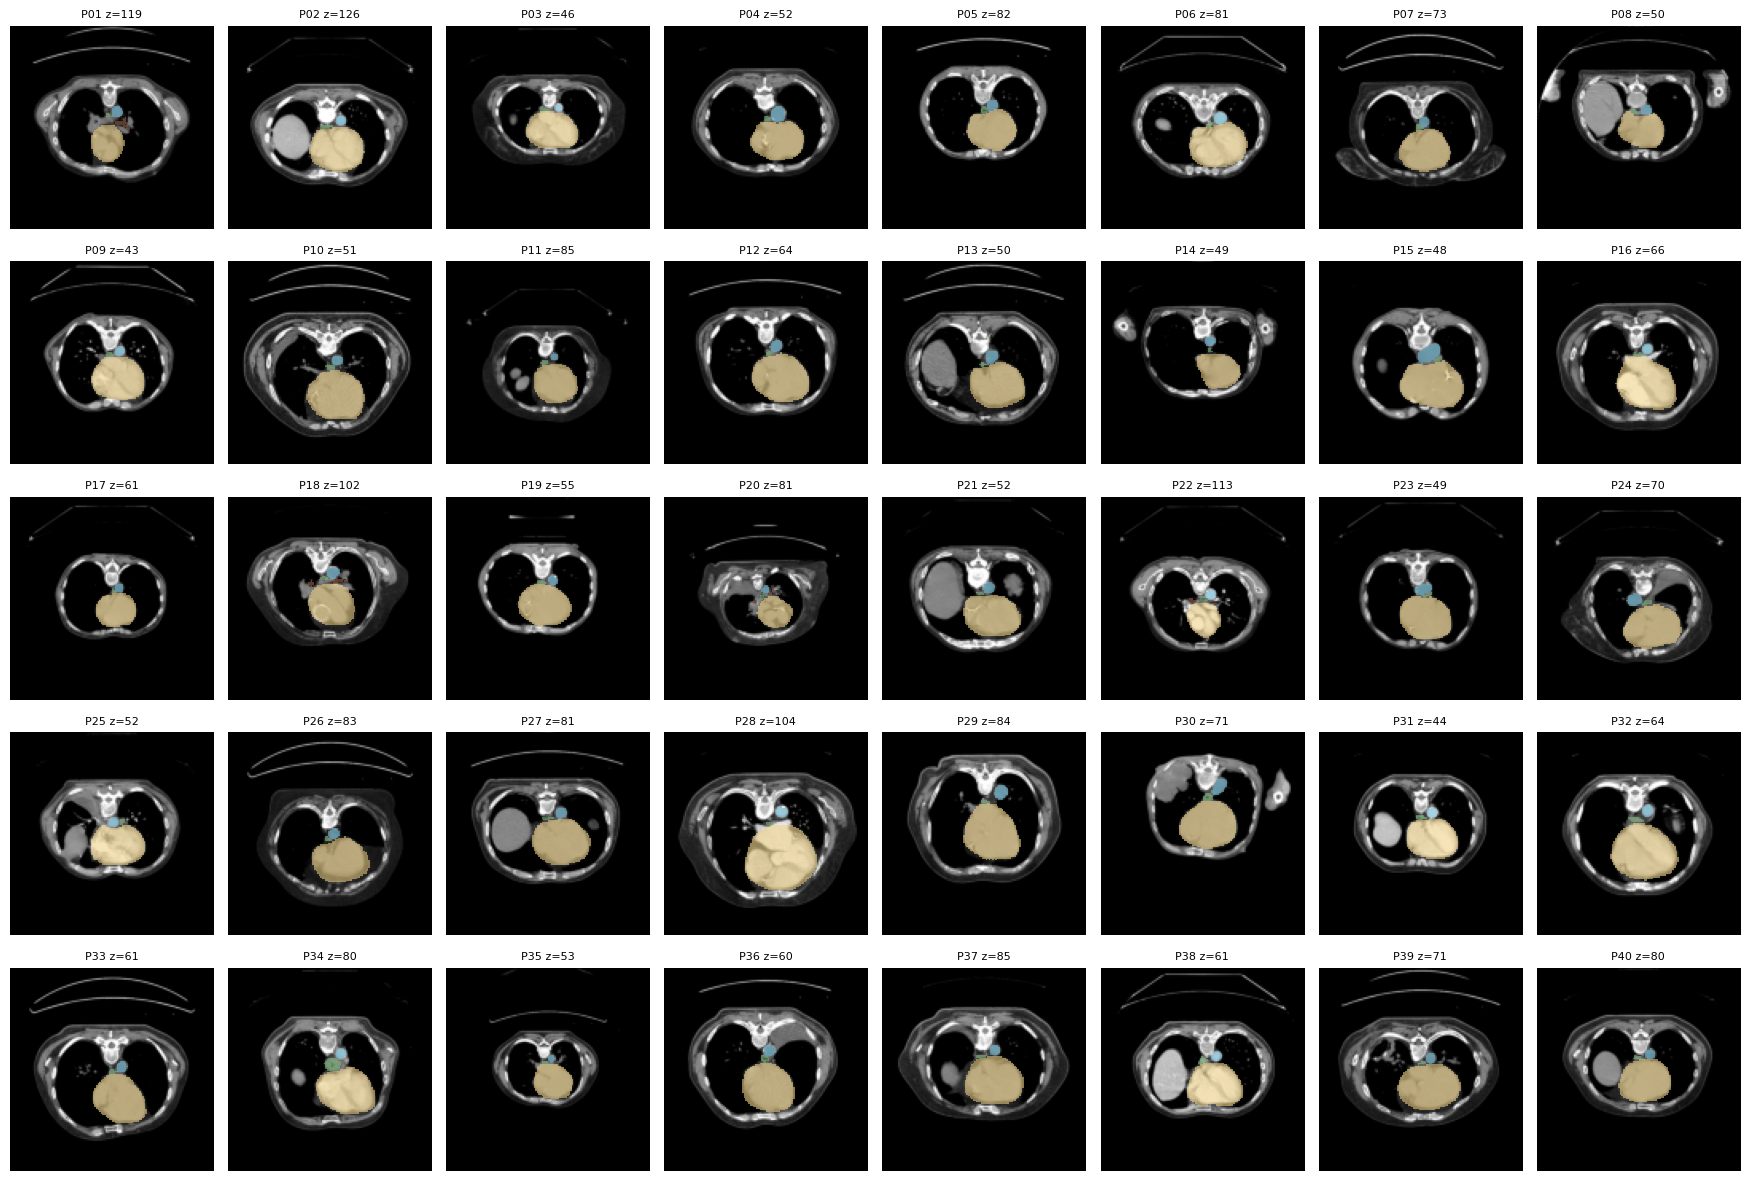

In [14]:
cols = min(8, len(thumbs)); rows = int(np.ceil(len(thumbs) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(2.2 * cols, 2.4 * rows), squeeze=False)
for ax in axes.ravel(): ax.axis("off")
for ax, (pid, z, img, lab) in zip(axes.ravel(), thumbs):
    ax.imshow(img.T, cmap="gray", vmin=0, vmax=1, origin="lower")
    ax.imshow(np.ma.masked_where(lab.T == 0, lab.T), cmap=LABEL_CMAP, vmin=.5, vmax=4.5,
              alpha=.55, origin="lower", interpolation="nearest")
    ax.set_title(f"{pid.replace('Patient_', 'P')} z={z}", fontsize=8)
fig.tight_layout()
save(fig, "07_label_montage.png"); plt.show()

## 13. Save a summary

In [15]:
def describe(s):
    s = pd.to_numeric(s, errors="coerce").dropna()
    return None if s.empty else {"min": float(s.min()), "median": float(s.median()),
                                 "max": float(s.max()), "mean": float(s.mean())}

summary = {
    "data_dir": str(DATA_DIR.resolve()), "n_train": int(len(train)), "n_test": len(test_scans),
    "orientations": sorted(df["orientation"].unique().tolist()),
    "n_slices": describe(df["n_slices"]), "spacing_xy_mm": describe(df["spacing_x"]),
    "spacing_z_mm": describe(df["spacing_z"]),
    "hu_p1": describe(df["hu_p1"]), "hu_p99": describe(df["hu_p99"]),
    "class_voxel_fraction": dict(zip(["background", *CLASS_NAMES.values()],
                                     (class_voxels / class_voxels.sum()).tolist())),
    "organ_volume_ml": {CLASS_NAMES[k]: describe(train[f"{CLASS_NAMES[k].lower()}_ml"]) for k in CLASS_NAMES},
    "organ_hu_median": {CLASS_NAMES[k]: float(np.median(organ_samples[k]))
                        for k in CLASS_NAMES if organ_samples[k].size},
    "warnings": warnings,
}
(DEST / "summary.json").write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))

{
  "data_dir": "C:\\Users\\Utente\\ai4mijGroup5\\data",
  "n_train": 40,
  "n_test": 0,
  "orientations": [
    "LPS"
  ],
  "n_slices": {
    "min": 147.0,
    "median": 177.5,
    "max": 284.0,
    "mean": 185.5
  },
  "spacing_xy_mm": {
    "min": 0.8964840173721313,
    "median": 0.9765620231628418,
    "max": 1.3671879768371582,
    "mean": 1.0014157146215439
  },
  "spacing_z_mm": {
    "min": 2.0,
    "median": 2.5,
    "max": 2.5,
    "mean": 2.35
  },
  "hu_p1": {
    "min": -1000.0,
    "median": -1000.0,
    "max": -1000.0,
    "mean": -1000.0
  },
  "hu_p99": {
    "min": 114.0,
    "median": 301.5,
    "max": 451.0,
    "mean": 292.975
  },
  "class_voxel_fraction": {
    "background": 0.989460198641466,
    "Esophagus": 0.0004547196257146542,
    "Heart": 0.0077738342902088425,
    "Trachea": 0.00034698733100993934,
    "Aorta": 0.0019642601116005623
  },
  "organ_volume_ml": {
    "Esophagus": {
      "min": 30.59384147644043,
      "median": 45.80493161201477,
      "m